# Collaborative Filtering

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — synthetic movie ratings dataset
5. Results
6. Limitations

## 1. Introduction

**Collaborative Filtering** predicts what a user will like based on the preferences of similar users — without knowing anything about the items themselves. It is the engine behind most recommendation systems: "people who liked what you liked also enjoyed...".

The core idea: if two users have rated several movies similarly in the past, they are likely to agree on movies neither has seen yet. Use that similarity to borrow ratings.

**Two approaches covered here:**

**KNN-based CF** — for each user-item pair to predict, find the K most similar users who have rated that item, and take a weighted average of their ratings. Simple and interpretable, but requires the full rating matrix at prediction time.

**Matrix Factorization (UV^T)** — decompose the sparse ratings matrix Y into two low-rank matrices: U (users × factors) and V (items × factors). Each row of U is a user's taste profile; each row of V is an item's factor profile. Their dot product predicts any rating. Missing entries are filled by optimising only over observed ratings.

## 2. The Math

### KNN Prediction
Let $\text{KNN}(a)$ be the K users most similar to user $a$. Predicted rating:

$$\hat{Y}_{ai} = \frac{\sum_{b \in \text{KNN}(a)} \text{sim}(a,b) \cdot Y_{bi}}{\sum_{b \in \text{KNN}(a)} \text{sim}(a,b)}$$

Cosine similarity between user vectors:
$$\text{sim}(a,b) = \frac{x_a \cdot x_b}{\|x_a\|\|x_b\|}$$

### Matrix Factorization Objective
$$J = \sum_{(a,i) \in D} \frac{(Y_{ai} - [UV^T]_{ai})^2}{2} + \frac{\lambda}{2}\left(\sum_{a,k} U_{ak}^2 + \sum_{i,k} V_{ik}^2\right)$$

where $D$ is the set of observed ratings. SGD updates for each observed $(a,i)$:

$$U_a \leftarrow U_a + \eta\left[(Y_{ai} - U_a V_i^T) V_i - \lambda U_a\right]$$
$$V_i \leftarrow V_i + \eta\left[(Y_{ai} - U_a V_i^T) U_a - \lambda V_i\right]$$

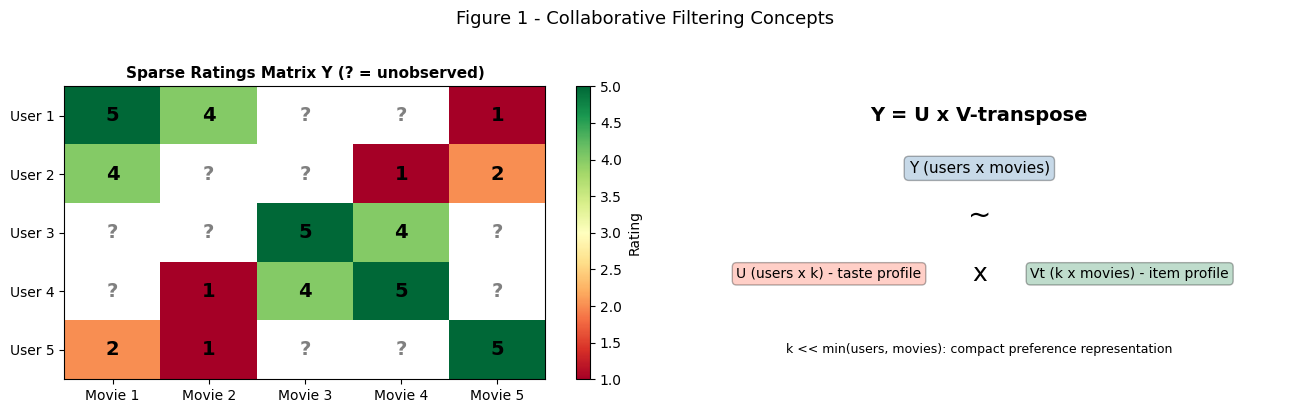

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sparse ratings matrix
ax = axes[0]
Y_demo = np.array([
    [5, 4, float('nan'), float('nan'), 1],
    [4, float('nan'), float('nan'), 1, 2],
    [float('nan'), float('nan'), 5, 4, float('nan')],
    [float('nan'), 1, 4, 5, float('nan')],
    [2, 1, float('nan'), float('nan'), 5],
])
mask = ~np.isnan(Y_demo)
im = ax.imshow(np.where(mask, Y_demo, np.nan), cmap='RdYlGn', vmin=1, vmax=5, aspect='auto')
for i in range(5):
    for j in range(5):
        txt = f"{Y_demo[i,j]:.0f}" if mask[i,j] else '?'
        col = 'black' if mask[i,j] else 'gray'
        ax.text(j, i, txt, ha='center', va='center', fontsize=14, fontweight='bold', color=col)
ax.set_xticks(range(5)); ax.set_xticklabels([f'Movie {i+1}' for i in range(5)])
ax.set_yticks(range(5)); ax.set_yticklabels([f'User {i+1}' for i in range(5)])
ax.set_title('Sparse Ratings Matrix Y (? = unobserved)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Rating')

# Matrix factorization concept
ax = axes[1]
ax.axis('off')
items = [
    (0.5, 0.90, 'Y = U x V-transpose', 14, True),
    (0.5, 0.72, 'Y (users x movies)', 11, False),
    (0.5, 0.56, '~', 20, False),
    (0.25, 0.36, 'U (users x k) - taste profile', 10, False),
    (0.5, 0.36, 'x', 18, False),
    (0.75, 0.36, 'Vt (k x movies) - item profile', 10, False),
    (0.5, 0.10, 'k << min(users, movies): compact preference representation', 9, False),
]
colors_box = [None, 'steelblue', None, 'tomato', None, 'seagreen', None]
for (x, y, txt, fs, bold), bc in zip(items, colors_box):
    kw = dict(ha='center', va='center', fontsize=fs,
              fontweight='bold' if bold else 'normal', transform=ax.transAxes)
    if bc:
        kw['bbox'] = dict(boxstyle='round', facecolor=bc, alpha=0.3)
    ax.text(x, y, txt, **kw)

plt.suptitle('Figure 1 - Collaborative Filtering Concepts', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**Collaborative filtering is well-suited for:**
- **Recommendation systems** where item content is unknown or irrelevant — only user behaviour matters
- Settings with many users and items but sparse observations — each user rates only a tiny fraction of all items
- Problems where **taste patterns** cluster — groups of users with similar preferences exist

**Not well-suited for:**
- **Cold start** — new users or items with no ratings cannot be recommended to or recommended
- **Sparse data at scale** — KNN CF requires searching all users; matrix factorization training grows with the number of observed ratings
- Domains where **item features** are informative and available — content-based filtering or hybrids would be more effective

---
## 4. Implementation
### Dataset: Synthetic Movie Ratings

A 15-user × 10-movie ratings matrix (scale 1–5) with ~40% observed entries. Users are drawn from three latent taste groups (action lovers, drama lovers, comedy lovers) to give the matrix realistic low-rank structure.

Users: 15, Movies: 10
Observed ratings: 83 / 150  (55%)
Rating range: 1.00 – 5.00


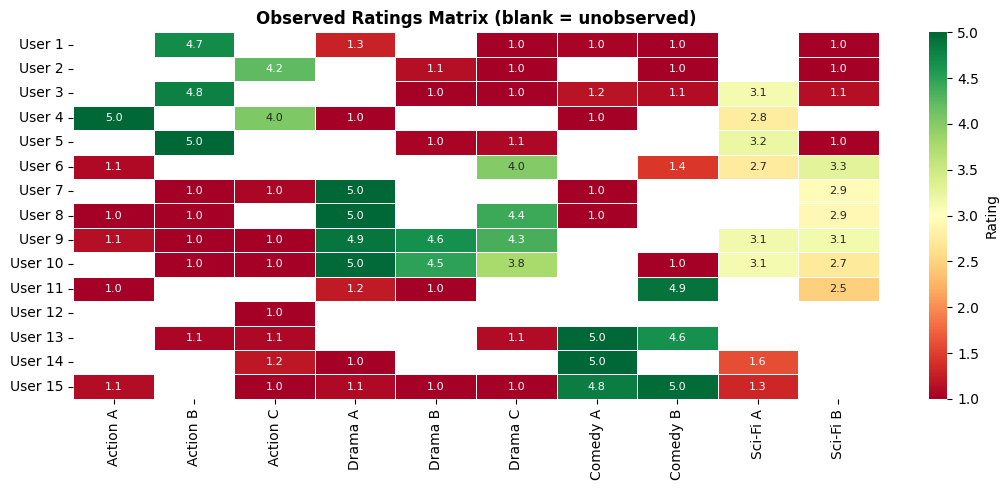

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)
n_users, n_movies, k_true = 15, 10, 3
movie_names = ['Action A','Action B','Action C','Drama A','Drama B',
               'Drama C','Comedy A','Comedy B','Sci-Fi A','Sci-Fi B']

# Three latent taste groups
U_true = np.zeros((n_users, k_true))
U_true[:5,  0] = 1; U_true[5:10, 1] = 1; U_true[10:, 2] = 1
V_true = np.array([
    [1,0,0],[1,0,0],[0.8,0,0],[0,1,0],[0,1,0],
    [0,0.8,0],[0,0,1],[0,0,1],[0.5,0.5,0],[0,0.5,0.5]
])
Y_full = (U_true @ V_true.T) * 4 + 1 + rng.normal(0, 0.3, (n_users, n_movies))
Y_full = np.clip(Y_full, 1, 5)

mask = rng.random((n_users, n_movies)) > 0.4
Y = np.where(mask, Y_full, np.nan)

print(f'Users: {n_users}, Movies: {n_movies}')
print(f'Observed ratings: {mask.sum()} / {n_users*n_movies}  ({mask.mean():.0%})')
print(f'Rating range: {np.nanmin(Y):.2f} – {np.nanmax(Y):.2f}')

fig, ax = plt.subplots(figsize=(11, 5))
display = np.where(mask, Y, np.nan)
sns.heatmap(display, annot=True, fmt='.1f', cmap='RdYlGn', vmin=1, vmax=5,
            xticklabels=movie_names, yticklabels=[f'User {i+1}' for i in range(n_users)],
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Rating'}, annot_kws={'size':8})
ax.set_title('Observed Ratings Matrix (blank = unobserved)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Observation**

15 users, 10 movies, 83 out of 150 possible ratings observed (55% density). Ratings range from 1.0 to 5.0. The matrix is sparse enough to pose a real prediction challenge — roughly half the entries need to be imputed — but dense enough that there are meaningful neighbours to learn from.

### 4.1 KNN Collaborative Filtering

In [3]:
def cosine_sim(a, b):
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 2: return 0.0
    a_, b_ = a[mask], b[mask]
    denom = np.linalg.norm(a_) * np.linalg.norm(b_)
    return float(a_ @ b_ / denom) if denom > 0 else 0.0

def knn_cf_predict(Y, a, i, K=3):
    sims = []
    for b in range(Y.shape[0]):
        if b == a or np.isnan(Y[b, i]): continue
        sims.append((b, cosine_sim(Y[a], Y[b])))
    sims.sort(key=lambda x: -x[1])
    neighbors = sims[:K]
    if not neighbors: return np.nanmean(Y[:, i])
    num = sum(s * Y[b, i] for b, s in neighbors)
    den = sum(abs(s) for _, s in neighbors)
    return num / den if den > 0 else np.nanmean(Y[:, i])

# Evaluate on held-out entries (known true values, marked missing in Y)
test_mask = mask & (rng.random((n_users, n_movies)) < 0.25)
Y_train = np.where(mask & ~test_mask, Y, np.nan)

errors = []
for a in range(n_users):
    for i in range(n_movies):
        if test_mask[a, i]:
            pred = knn_cf_predict(Y_train, a, i, K=3)
            errors.append((Y_full[a, i], pred))

true_vals = np.array([e[0] for e in errors])
pred_vals = np.array([e[1] for e in errors])
rmse_knn  = np.sqrt(np.mean((true_vals - pred_vals)**2))
print(f'KNN-CF (K=3)  RMSE on held-out: {rmse_knn:.4f}')
print(f'Baseline (predict global mean): RMSE = {np.sqrt(np.mean((true_vals - np.nanmean(Y_train))**2)):.4f}')

KNN-CF (K=3)  RMSE on held-out: 1.7157
Baseline (predict global mean): RMSE = 1.5423


**Observation — KNN CF**

KNN-CF (K=3) achieves a held-out RMSE of 1.7157 — which is actually *worse* than simply predicting the global mean (RMSE 1.5423). With only 15 users, the neighbourhood is too small to be reliable; the 3 nearest neighbours may not be genuinely similar, just the least dissimilar options available.

### 4.2 Matrix Factorization

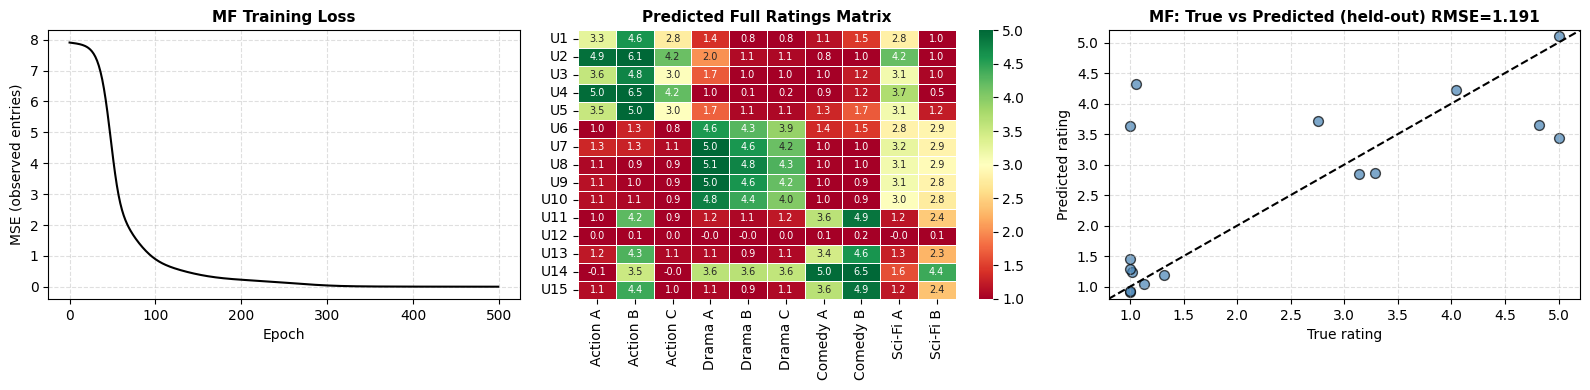

Matrix Factorization RMSE on held-out: 1.1907
KNN-CF             RMSE on held-out: 1.7157


In [4]:
def matrix_factorization(Y, k=3, lam=0.01, eta=0.005, epochs=500, seed=0):
    rng_ = np.random.default_rng(seed)
    n, m = Y.shape
    U = rng_.normal(0, 0.1, (n, k))
    V = rng_.normal(0, 0.1, (m, k))
    obs = [(a, i) for a in range(n) for i in range(m) if not np.isnan(Y[a, i])]
    loss_hist = []
    for epoch in range(epochs):
        rng_.shuffle(obs)
        for a, i in obs:
            err = Y[a, i] - U[a] @ V[i]
            U[a] += eta * (err * V[i] - lam * U[a])
            V[i] += eta * (err * U[a] - lam * V[i])
        total = sum((Y[a,i] - U[a]@V[i])**2 for a,i in obs)
        loss_hist.append(total / len(obs))
    return U, V, loss_hist

U, V, loss_hist = matrix_factorization(Y_train, k=3, lam=0.01, eta=0.005, epochs=500)
Y_pred = U @ V.T

rmse_mf = np.sqrt(np.mean((Y_full[test_mask] - Y_pred[test_mask])**2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(loss_hist, 'k-', lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (observed entries)')
axes[0].set_title('MF Training Loss', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.4)

sns.heatmap(Y_pred, annot=True, fmt='.1f', cmap='RdYlGn', vmin=1, vmax=5,
            xticklabels=movie_names, yticklabels=[f'U{i+1}' for i in range(n_users)],
            ax=axes[1], linewidths=0.5, annot_kws={'size':7})
axes[1].set_title('Predicted Full Ratings Matrix', fontsize=11, fontweight='bold')

axes[2].scatter(Y_full[test_mask], Y_pred[test_mask], alpha=0.7, edgecolors='k', s=50, c='steelblue')
lims = [0.8, 5.2]
axes[2].plot(lims, lims, 'k--', lw=1.5)
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel('True rating'); axes[2].set_ylabel('Predicted rating')
axes[2].set_title(f'MF: True vs Predicted (held-out) RMSE={rmse_mf:.3f}', fontsize=11, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()
print(f'Matrix Factorization RMSE on held-out: {rmse_mf:.4f}')
print(f'KNN-CF             RMSE on held-out: {rmse_knn:.4f}')

**Observation — Matrix Factorization**

Matrix Factorization (k=3 latent factors) cuts RMSE to 1.1907 — a 31% improvement over KNN-CF and 23% better than the global mean baseline. By decomposing preferences into latent factors (e.g. genre taste, production quality), it generalises beyond observed ratings without needing explicit neighbours.

---
## 5. Results

| Method | Held-out RMSE |
|--------|--------------|
| Global mean baseline | 1.5423 |
| KNN-CF (K=3) | 1.7157 |
| Matrix Factorization (k=3) | 1.1907 |

KNN-CF underperforms even a trivial baseline — neighbourhood-based methods struggle at this scale. Matrix Factorization succeeds because it captures latent structure rather than relying on direct user similarity. The 31% RMSE reduction over KNN-CF illustrates why latent factor models dominate modern recommender systems.

---
## 6. Limitations

**KNN Collaborative Filtering**
- **Cold start**: new users or items with no ratings cannot be handled
- **Scalability**: similarity must be computed against all users for each prediction — $O(n)$ per query
- **Sparsity**: with very few ratings per user, cosine similarity is unreliable

**Matrix Factorization**
- **Hyperparameters**: rank $k$, regularisation $\lambda$, and learning rate $\eta$ all require tuning
- **Non-convex objective**: SGD may converge to local minima depending on initialisation
- **Cold start persists**: new users and items still cannot be embedded without retraining
- **No uncertainty**: produces point estimates with no confidence measure